### Técnica XGBoost

**Carga de datos desde MinIO**

In [1]:
import os
import sys
import pandas as pd
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

ruta_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ruta_raiz not in sys.path:
    sys.path.insert(0, ruta_raiz)


access_key = os.getenv("MINIO_ACCESS_KEY")
if access_key is None:
    raise AssertionError("MINIO_ACCESS_KEY no definida.")

secret_key = os.getenv("MINIO_SECRET_KEY")
if secret_key is None:
    raise AssertionError("MINIO_SECRET_KEY no definida.")


meses = ['01', '02']
dfs = []

for mes in meses:
    try:
        s = download_df_parquet(
            access_key=access_key,
            secret_key=secret_key,
            object_name=f"grupo5/final/year=2025/month={mes}/dataset_final.parquet",
        )
        dfs.append(s)
    except Exception as e:
        print(f"  Sin datos para mes {mes}: {e}")

df = pd.concat(dfs, ignore_index=True)

print(f"¡Descarga exitosa! {len(meses)} meses")
print(f"  df: {len(df):,} filas")


¡Descarga exitosa! 2 meses
  df: 12,085,095 filas


**Creación de nuevas features para una ventana de tiempo más amplia**

In [2]:
#Ordenamos por línea, parada y timestamp
df = df.sort_values(['route_id', 'stop_id', 'merge_time'])
grupo = ['route_id', 'stop_id']

#Creación de nuevas variables de delay para poder ampliar la ventana de observaciones a 30 minutos aproximadamente
df['lagged_delay_3'] = df.groupby(grupo)['delay_seconds'].shift(3)
df['lagged_delay_4'] = df.groupby(grupo)['delay_seconds'].shift(4)

#Tendencia en el retraso
df['delay_trend'] = df['lagged_delay_1'] - df['lagged_delay_4']

#Inestabilidad reciente de la línea
df['delay_std'] = df.groupby(grupo)['delay_seconds'].transform(
    lambda x: x.shift(1).rolling(4).std()
)

cols_lag = ['lagged_delay_1', 'lagged_delay_2', 'lagged_delay_3', 'lagged_delay_4']
df[cols_lag] = df[cols_lag].fillna(0)

**Selección de features y target**

In [3]:
#Seleccion de variables
features = [
    'delay_seconds', 'lagged_delay_1', 'lagged_delay_2',
    'lagged_delay_3', 'lagged_delay_4', 'delay_trend',
    'route_rolling_delay', 'actual_headway_seconds',
    'is_unscheduled', 'num_updates', 'scheduled_time_to_end',
    'stops_to_end', 'route_id', 'direction', 'delay_std',
    'hour_sin', 'hour_cos', 'dow', 'is_weekend',
    'n_eventos_afectando', 'tipo_referente',
    'afecta_previo', 'afecta_durante', 'afecta_despues',
    'temp_extreme', 'category',
]
target = 'alert_in_next_15m'


# Eliminar filas sin target
df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(int)

**Filtro que elimina paradas que no tienen alerta en 15m pero su comportamiento puede estar alterado por alerta en 30m**

In [4]:
mask_positivos = df[target] == 1
mask_negativos_limpios = (
    df['alert_in_next_30m'] == 0            
)

df = df[mask_positivos | mask_negativos_limpios].copy()
df = df.reset_index(drop=True)

print(f"Dataset tras filtrar negativos ambiguos: {len(df):,} filas")
print(f"  Positivos: {df[target].sum():,} ({df[target].mean()*100:.1f}%)")
print(f"  Negativos: {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%)")

Dataset tras filtrar negativos ambiguos: 11,341,612 filas
  Positivos: 1,093,820 (9.6%)
  Negativos: 10,247,792 (90.4%)


**División de los datos en Train-Val-Test**

In [5]:
df_sorted = df.sort_values('merge_time')

#Division X e y
X = df_sorted[features]
y = df_sorted[target]

print(f"Features: {len(features)}")
print(f"Filas:    {len(X):,}")
print(f"\nDistribución del target:")
print(y.value_counts(normalize=True).round(3))


#División de los datos en Entrenamiento-Validación-Test

dias = df_sorted['merge_time'].dt.date.unique()
dias_ordenados = sorted(dias)

total_dias = len(dias_ordenados)
corte_70   = dias_ordenados[int(total_dias * 0.70)]
corte_85   = dias_ordenados[int(total_dias * 0.85)]

print(f"Total días: {total_dias}")
print(f"Primer día: {dias_ordenados[0]}")
print(f"Último día: {dias_ordenados[-1]}")
print(f"\nCorte train (70%): {corte_70}")
print(f"Corte val   (85%): {corte_85}")


train = df_sorted[df_sorted['merge_time'].dt.date <  corte_70]
val   = df_sorted[(df_sorted['merge_time'].dt.date >= corte_70) &
           (df_sorted['merge_time'].dt.date <  corte_85)]
test  = df_sorted[df_sorted['merge_time'].dt.date >= corte_85]

X_train, y_train = train[features], train[target]
X_val,   y_val   = val[features],   val[target]
X_test,  y_test  = test[features],  test[target]

n = len(df)
print(f"Train: {len(train):,} ({len(train)/n*100:.0f}%)  "
      f"{train['merge_time'].min().date()} → {train['merge_time'].max().date()}")
print(f"Val:   {len(val):,} ({len(val)/n*100:.0f}%)  "
      f"{val['merge_time'].min().date()} → {val['merge_time'].max().date()}")
print(f"Test:  {len(test):,} ({len(test)/n*100:.0f}%)  "
      f"{test['merge_time'].min().date()} → {test['merge_time'].max().date()}")


Features: 26
Filas:    11,341,612

Distribución del target:
alert_in_next_15m
0    0.904
1    0.096
Name: proportion, dtype: float64
Total días: 59
Primer día: 2025-01-01
Último día: 2025-02-28

Corte train (70%): 2025-02-11
Corte val   (85%): 2025-02-20
Train: 7,845,635 (69%)  2025-01-01 → 2025-02-10
Val:   1,699,581 (15%)  2025-02-11 → 2025-02-19
Test:  1,796,396 (16%)  2025-02-20 → 2025-02-28


**Encoding de categorías**

In [6]:
#Encodear categorías

from sklearn.preprocessing import OrdinalEncoder
import category_encoders as ce

cols_target_enc  = ['category', 'tipo_referente'] 
cols_ordinal_enc = ['route_id', 'direction']   

#Target Encoding
te = ce.TargetEncoder(cols=cols_target_enc, smoothing=10) 
X_train[cols_target_enc] = te.fit_transform(X_train[cols_target_enc], y_train)
X_val[cols_target_enc]   = te.transform(X_val[cols_target_enc])
X_test[cols_target_enc]  = te.transform(X_test[cols_target_enc])

#Ordinal Encoding
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cols_ordinal_enc] = enc.fit_transform(X_train[cols_ordinal_enc])
X_val[cols_ordinal_enc]   = enc.transform(X_val[cols_ordinal_enc])
X_test[cols_ordinal_enc]  = enc.transform(X_test[cols_ordinal_enc])

print("✓ Encoding completado")

✓ Encoding completado


**Búsqueda de los mejores hiperparámetros empleando optuna**

In [7]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score, classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              recall_score, precision_score)

# Ratio de desbalance para scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio desbalance: {ratio:.1f}:1")

def objective(trial):
    params = {
        'max_depth':          trial.suggest_int('max_depth', 3, 10),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 100),
        'gamma':              trial.suggest_float('gamma', 0, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':       trial.suggest_int('n_estimators', 200, 800),
        'subsample':          trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-6, 100, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-6, 100, log=True),
        'max_delta_step':     trial.suggest_float('max_delta_step', 0, 10),
        'scale_pos_weight':   ratio,
        'tree_method':        'hist',
        'eval_metric':        'aucpr',
        'early_stopping_rounds': 30,
    }
    modelo = XGBClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = modelo.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=45)
print(study.best_params)

c:\Users\Sergio\c2526-R5\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-23 21:03:26,482] A new study created in memory with name: no-name-bac57a7c-8f50-4d97-b4b4-39d2dd672ff5


Ratio desbalance: 9.3:1


[I 2026-03-23 21:04:11,581] Trial 0 finished with value: 0.21294530786795698 and parameters: {'max_depth': 9, 'min_child_weight': 47, 'gamma': 6.596230729158609, 'learning_rate': 0.16384510717340936, 'n_estimators': 466, 'subsample': 0.8035088789484652, 'colsample_bytree': 0.8662902323467205, 'colsample_bylevel': 0.5709039720624205, 'reg_alpha': 0.4376197536234564, 'reg_lambda': 0.003518624518706849, 'max_delta_step': 8.827311767277891}. Best is trial 0 with value: 0.21294530786795698.
[I 2026-03-23 21:04:41,076] Trial 1 finished with value: 0.20591235097201668 and parameters: {'max_depth': 7, 'min_child_weight': 100, 'gamma': 3.1213339232502593, 'learning_rate': 0.12290646261206033, 'n_estimators': 644, 'subsample': 0.9000781545811646, 'colsample_bytree': 0.8527603147998052, 'colsample_bylevel': 0.8224954261081279, 'reg_alpha': 16.250872550957446, 'reg_lambda': 2.302987827511444e-06, 'max_delta_step': 8.443982713007156}. Best is trial 0 with value: 0.21294530786795698.
[I 2026-03-23 2

{'max_depth': 9, 'min_child_weight': 22, 'gamma': 2.54429488214286, 'learning_rate': 0.0853236132780729, 'n_estimators': 381, 'subsample': 0.757656058617785, 'colsample_bytree': 0.8166574873597842, 'colsample_bylevel': 0.8088842013148931, 'reg_alpha': 0.0001313663694771374, 'reg_lambda': 4.090549809883547e-06, 'max_delta_step': 8.635586179736665}


**Entrenamiento del modelo empleando los mejores parámetros**

In [8]:
best_params = study.best_params

params_fijos = {
    'n_estimators': 500,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'aucpr',
    'random_state': 42
}

parametros = {**params_fijos, **best_params}

modelo_final = XGBClassifier(**parametros)
modelo_final.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.8088842013148931
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8166574873597842
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.da

**Evaluacion del modelo**

In [9]:
import numpy as np

#Evaluación del modelo

y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Threshold óptimo por F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int),
                        zero_division=0) for t in thresholds]
threshold_opt = thresholds[np.argmax(f1_scores)]
y_pred = (y_prob >= threshold_opt).astype(int)


print(f"Threshold óptimo: {threshold_opt:.2f}")
print(f"\nAUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob):.4f}")
print(f"F1      : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

Threshold óptimo: 0.46

AUC-ROC : 0.6417
PR-AUC  : 0.1416
F1      : 0.1900
Recall  : 0.5783
Precision: 0.1137

              precision    recall  f1-score   support

           0       0.94      0.60      0.74   1651475
           1       0.11      0.58      0.19    144921

    accuracy                           0.60   1796396
   macro avg       0.53      0.59      0.46   1796396
weighted avg       0.88      0.60      0.69   1796396



**Curva Precision-Recall con area sombreada**

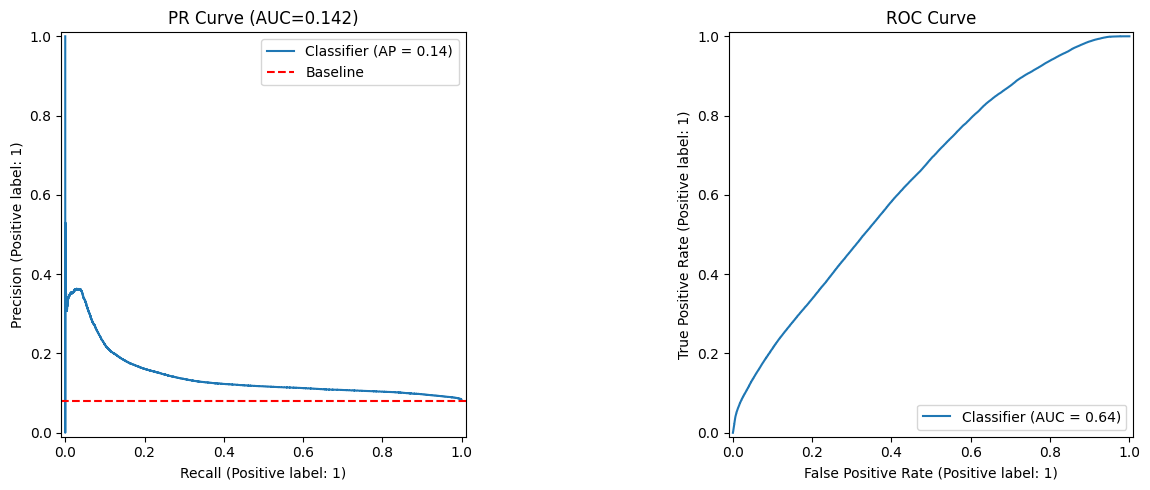

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title(f'PR Curve (AUC={average_precision_score(y_test, y_prob):.3f})')
axes[0].axhline(y=y_test.mean(), color='r', linestyle='--', label='Baseline')
axes[0].legend()

# Curva ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()

**Importancia de features con SHAP**

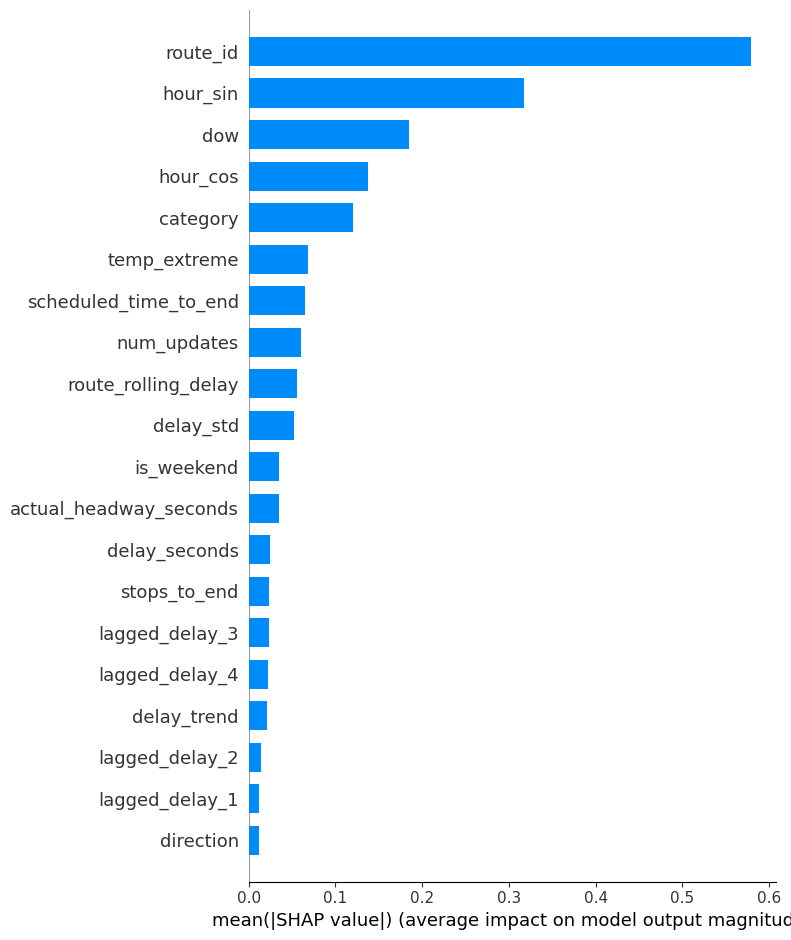

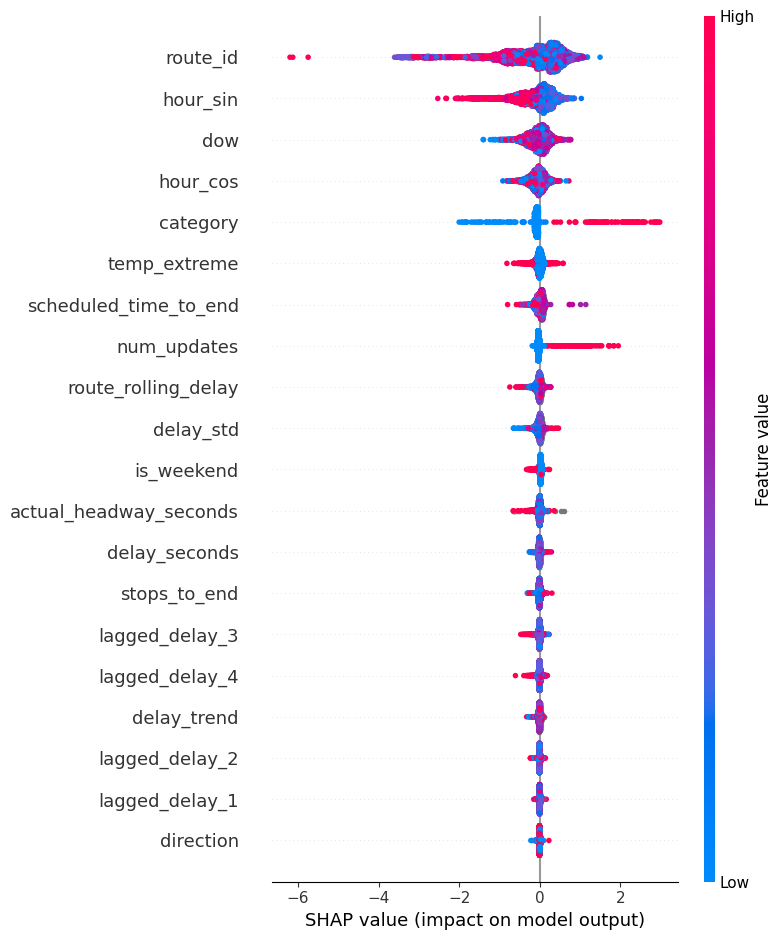

In [11]:
import shap

# Muestra aleatoria para SHAP (costoso con 1.8M filas)
sample = X_test.sample(5000, random_state=42)
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar')   # importancia global
shap.summary_plot(shap_values, sample)                     # dirección del efecto

**Matriz de confusión con costes**

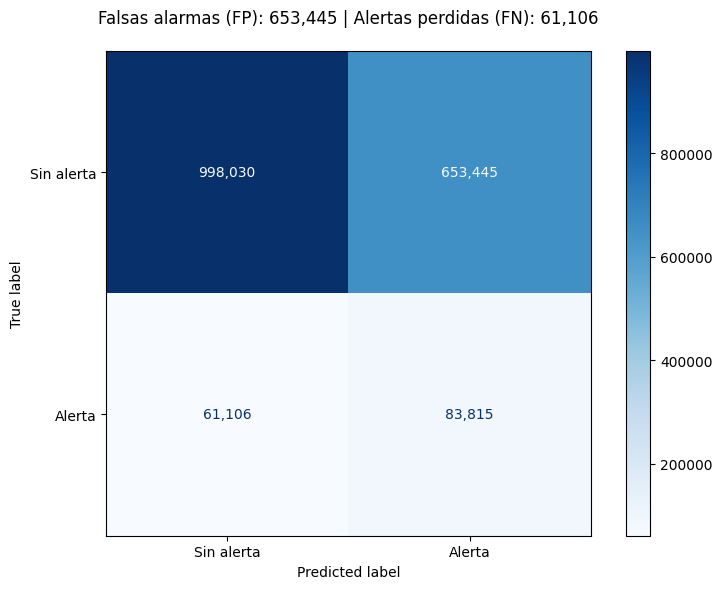

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=['Sin alerta', 'Alerta'],
    cmap='Blues',
    ax=ax,
    values_format=',d'
)

fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

ax.set_title(f'Falsas alarmas (FP): {fp:,} | Alertas perdidas (FN): {fn:,}', 
             pad=20,     
             fontsize=12)

plt.tight_layout() 
plt.show()

### Distribución por linea

**Carga de datos desde MinIO**

In [13]:
import os
import sys
import pandas as pd
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

ruta_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ruta_raiz not in sys.path:
    sys.path.insert(0, ruta_raiz)


access_key = os.getenv("MINIO_ACCESS_KEY")
if access_key is None:
    raise AssertionError("MINIO_ACCESS_KEY no definida.")

secret_key = os.getenv("MINIO_SECRET_KEY")
if secret_key is None:
    raise AssertionError("MINIO_SECRET_KEY no definida.")


lineas = ['1', '2']
dfs = []

for linea in lineas:
    try:
        s = download_df_parquet(
            access_key=access_key,
            secret_key=secret_key,
            object_name=f"grupo5/aggregations/lines/line={linea}/dataset_final.parquet",
        )
        dfs.append(s)
    except Exception as e:
        print(f"  Sin datos para linea {linea}: {e}")

df = pd.concat(dfs, ignore_index=True)

print(f"¡Descarga exitosa! {len(lineas)} lineas")
print(f"  df: {len(df):,} filas")


¡Descarga exitosa! 2 lineas
  df: 9,823,596 filas


**Creación de nuevas features para una ventana de tiempo más amplia**

In [14]:
#Ordenamos por línea, parada y timestamp
df = df.sort_values(['route_id', 'stop_id', 'merge_time'])
grupo = ['route_id', 'stop_id']

#Creación de nuevas variables de delay para poder ampliar la ventana de observaciones a 30 minutos aproximadamente
df['lagged_delay_3'] = df.groupby(grupo)['delay_seconds'].shift(3)
df['lagged_delay_4'] = df.groupby(grupo)['delay_seconds'].shift(4)

#Tendencia en el retraso
df['delay_trend'] = df['lagged_delay_1'] - df['lagged_delay_4']

#Inestabilidad reciente de la línea
df['delay_std'] = df.groupby(grupo)['delay_seconds'].transform(
    lambda x: x.shift(1).rolling(4).std()
)

#Eliminar filas con NaN en lagged features
cols_lag = ['lagged_delay_1', 'lagged_delay_2', 'lagged_delay_3', 'lagged_delay_4']
df[cols_lag] = df[cols_lag].fillna(0)

**Selección de features y target**

In [15]:
#Seleccion de variables
features = [
    'delay_seconds', 'lagged_delay_1', 'lagged_delay_2',
    'lagged_delay_3', 'lagged_delay_4', 'delay_trend',
    'route_rolling_delay', 'actual_headway_seconds',
    'is_unscheduled', 'num_updates', 'scheduled_time_to_end',
    'stops_to_end', 'route_id', 'direction', 'delay_std',
    'hour_sin', 'hour_cos', 'dow', 'is_weekend',
    'n_eventos_afectando', 'tipo_referente',
    'afecta_previo', 'afecta_durante', 'afecta_despues',
    'temp_extreme', 'category',
]
target = 'alert_in_next_15m'


# Eliminar filas sin target
df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(int)

**Filtro que elimina paradas que no tienen alerta en 15m pero su comportamiento puede estar alterado por alerta en 30m**

In [16]:
mask_positivos = df[target] == 1
mask_negativos_limpios = (
    df['alert_in_next_30m'] == 0            
)

df = df[mask_positivos | mask_negativos_limpios].copy()
df = df.reset_index(drop=True)

print(f"Dataset tras filtrar negativos ambiguos: {len(df):,} filas")
print(f"  Positivos: {df[target].sum():,} ({df[target].mean()*100:.1f}%)")
print(f"  Negativos: {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%)")

Dataset tras filtrar negativos ambiguos: 9,200,284 filas
  Positivos: 938,914 (10.2%)
  Negativos: 8,261,370 (89.8%)


**División de los datos en Train-Val-Test**

In [17]:
df_sorted = df.sort_values('merge_time')

#Division X e y
X = df_sorted[features]
y = df_sorted[target]

print(f"Features: {len(features)}")
print(f"Filas:    {len(X):,}")
print(f"\nDistribución del target:")
print(y.value_counts(normalize=True).round(3))


#División de los datos en Entrenamiento-Validación-Test

dias = df_sorted['merge_time'].dt.date.unique()
dias_ordenados = sorted(dias)

total_dias = len(dias_ordenados)
corte_70   = dias_ordenados[int(total_dias * 0.70)]
corte_85   = dias_ordenados[int(total_dias * 0.85)]

print(f"Total días: {total_dias}")
print(f"Primer día: {dias_ordenados[0]}")
print(f"Último día: {dias_ordenados[-1]}")
print(f"\nCorte train (70%): {corte_70}")
print(f"Corte val   (85%): {corte_85}")


train = df_sorted[df_sorted['merge_time'].dt.date <  corte_70]
val   = df_sorted[(df_sorted['merge_time'].dt.date >= corte_70) &
           (df_sorted['merge_time'].dt.date <  corte_85)]
test  = df_sorted[df_sorted['merge_time'].dt.date >= corte_85]

X_train, y_train = train[features], train[target]
X_val,   y_val   = val[features],   val[target]
X_test,  y_test  = test[features],  test[target]

n = len(df)
print(f"Train: {len(train):,} ({len(train)/n*100:.0f}%)  "
      f"{train['merge_time'].min().date()} → {train['merge_time'].max().date()}")
print(f"Val:   {len(val):,} ({len(val)/n*100:.0f}%)  "
      f"{val['merge_time'].min().date()} → {val['merge_time'].max().date()}")
print(f"Test:  {len(test):,} ({len(test)/n*100:.0f}%)  "
      f"{test['merge_time'].min().date()} → {test['merge_time'].max().date()}")


Features: 26
Filas:    9,200,284

Distribución del target:
alert_in_next_15m
0    0.898
1    0.102
Name: proportion, dtype: float64
Total días: 365
Primer día: 2025-01-01
Último día: 2025-12-31

Corte train (70%): 2025-09-13
Corte val   (85%): 2025-11-07
Train: 6,423,645 (70%)  2025-01-01 → 2025-09-12
Val:   1,436,079 (16%)  2025-09-13 → 2025-11-06
Test:  1,340,560 (15%)  2025-11-07 → 2025-12-31


**Encoding de categorías**

In [18]:
#Encodear categorías

from sklearn.preprocessing import OrdinalEncoder
import category_encoders as ce

cols_target_enc  = ['category', 'tipo_referente'] 
cols_ordinal_enc = ['route_id', 'direction']   

#Target Encoding
te = ce.TargetEncoder(cols=cols_target_enc, smoothing=10) 
X_train[cols_target_enc] = te.fit_transform(X_train[cols_target_enc], y_train)
X_val[cols_target_enc]   = te.transform(X_val[cols_target_enc])
X_test[cols_target_enc]  = te.transform(X_test[cols_target_enc])

#Ordinal Encoding
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cols_ordinal_enc] = enc.fit_transform(X_train[cols_ordinal_enc])
X_val[cols_ordinal_enc]   = enc.transform(X_val[cols_ordinal_enc])
X_test[cols_ordinal_enc]  = enc.transform(X_test[cols_ordinal_enc])

print("✓ Encoding completado")

✓ Encoding completado


**Búsqueda de los mejores hiperparámetros empleando optuna**

In [19]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score, classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              recall_score, precision_score)

# Ratio de desbalance para scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio desbalance: {ratio:.1f}:1")

def objective(trial):
    params = {
        'max_depth':          trial.suggest_int('max_depth', 3, 10),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 100),
        'gamma':              trial.suggest_float('gamma', 0, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':       trial.suggest_int('n_estimators', 200, 800),
        'subsample':          trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-6, 100, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-6, 100, log=True),
        'max_delta_step':     trial.suggest_float('max_delta_step', 0, 10),
        'scale_pos_weight':   ratio,
        'tree_method':        'hist',
        'eval_metric':        'aucpr',
        'early_stopping_rounds': 30,
    }
    modelo = XGBClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = modelo.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=45)
print(study.best_params)

[I 2026-03-23 22:01:12,859] A new study created in memory with name: no-name-0d4a15cb-9c7d-43b6-9129-0af290158d74


Ratio desbalance: 8.6:1


[I 2026-03-23 22:01:35,103] Trial 0 finished with value: 0.23375148276735605 and parameters: {'max_depth': 3, 'min_child_weight': 96, 'gamma': 3.6779592194756305, 'learning_rate': 0.013332822263935357, 'n_estimators': 776, 'subsample': 0.8922638902781856, 'colsample_bytree': 0.6291860477154856, 'colsample_bylevel': 0.7333128646337567, 'reg_alpha': 0.003057888355240641, 'reg_lambda': 51.09030791412949, 'max_delta_step': 5.465420117452542}. Best is trial 0 with value: 0.23375148276735605.
[I 2026-03-23 22:01:58,452] Trial 1 finished with value: 0.22033523243816672 and parameters: {'max_depth': 5, 'min_child_weight': 41, 'gamma': 4.558890469651987, 'learning_rate': 0.07553320291838621, 'n_estimators': 595, 'subsample': 0.63699731692144, 'colsample_bytree': 0.6349938994808344, 'colsample_bylevel': 0.8374734226653004, 'reg_alpha': 0.017405668606386544, 'reg_lambda': 7.027044203922795e-06, 'max_delta_step': 1.780924016196176}. Best is trial 0 with value: 0.23375148276735605.
[I 2026-03-23 22

{'max_depth': 3, 'min_child_weight': 96, 'gamma': 3.6779592194756305, 'learning_rate': 0.013332822263935357, 'n_estimators': 776, 'subsample': 0.8922638902781856, 'colsample_bytree': 0.6291860477154856, 'colsample_bylevel': 0.7333128646337567, 'reg_alpha': 0.003057888355240641, 'reg_lambda': 51.09030791412949, 'max_delta_step': 5.465420117452542}


**Entrenamiento del modelo empleando los mejores parámetros**

In [20]:
best_params = study.best_params

params_fijos = {
    'n_estimators': 500,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'aucpr',
    'random_state': 42
}

parametros = {**params_fijos, **best_params}

modelo_final = XGBClassifier(**parametros)
modelo_final.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.7333128646337567
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6291860477154856
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.da

**Evaluacion del modelo**

In [21]:
import numpy as np

#Evaluación del modelo

y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Threshold óptimo por F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int),
                        zero_division=0) for t in thresholds]
threshold_opt = thresholds[np.argmax(f1_scores)]
y_pred = (y_prob >= threshold_opt).astype(int)


print(f"Threshold óptimo: {threshold_opt:.2f}")
print(f"\nAUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob):.4f}")
print(f"F1      : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

Threshold óptimo: 0.53

AUC-ROC : 0.6411
PR-AUC  : 0.2194
F1      : 0.2575
Recall  : 0.5061
Precision: 0.1727

              precision    recall  f1-score   support

           0       0.92      0.71      0.80   1196333
           1       0.17      0.51      0.26    144227

    accuracy                           0.69   1340560
   macro avg       0.55      0.61      0.53   1340560
weighted avg       0.84      0.69      0.74   1340560



**Curva Precision-Recall con area sombreada**

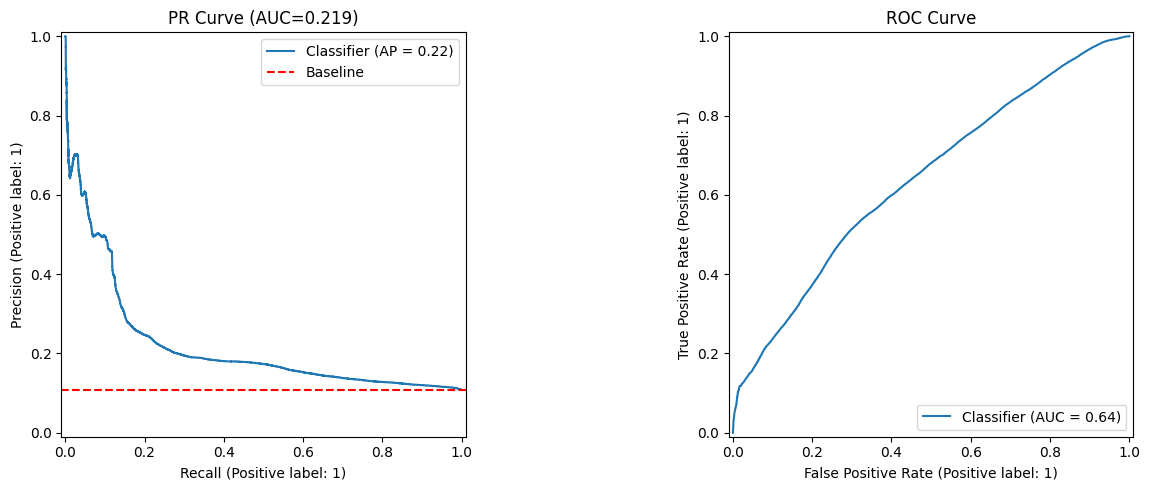

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title(f'PR Curve (AUC={average_precision_score(y_test, y_prob):.3f})')
axes[0].axhline(y=y_test.mean(), color='r', linestyle='--', label='Baseline')
axes[0].legend()

# Curva ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()

**Importancia de features con SHAP**

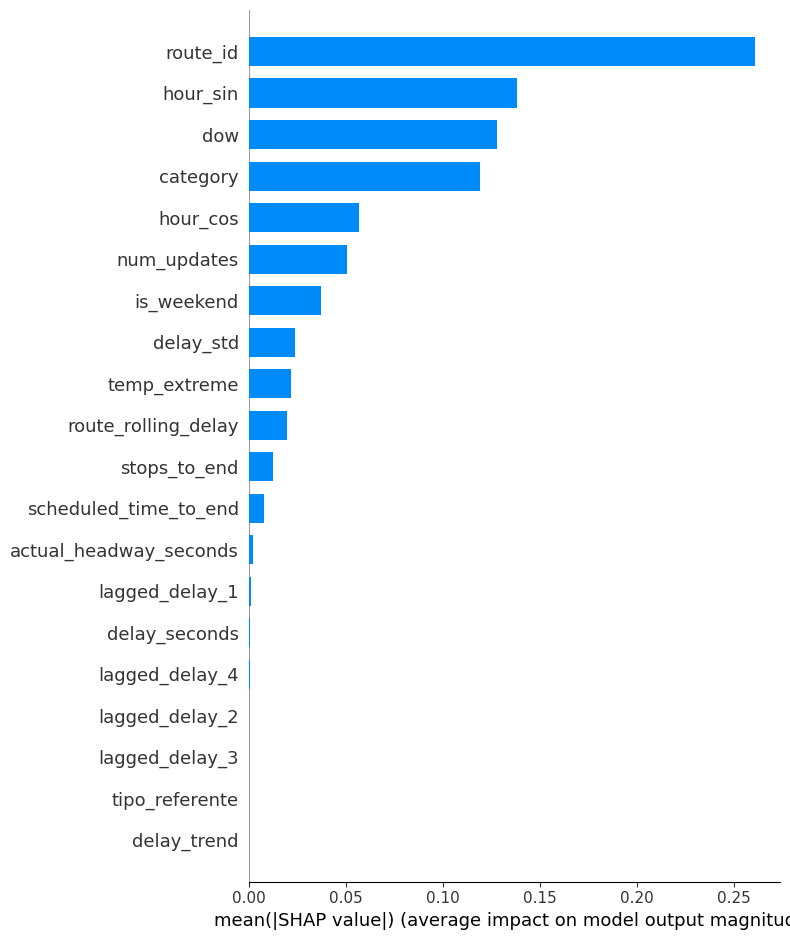

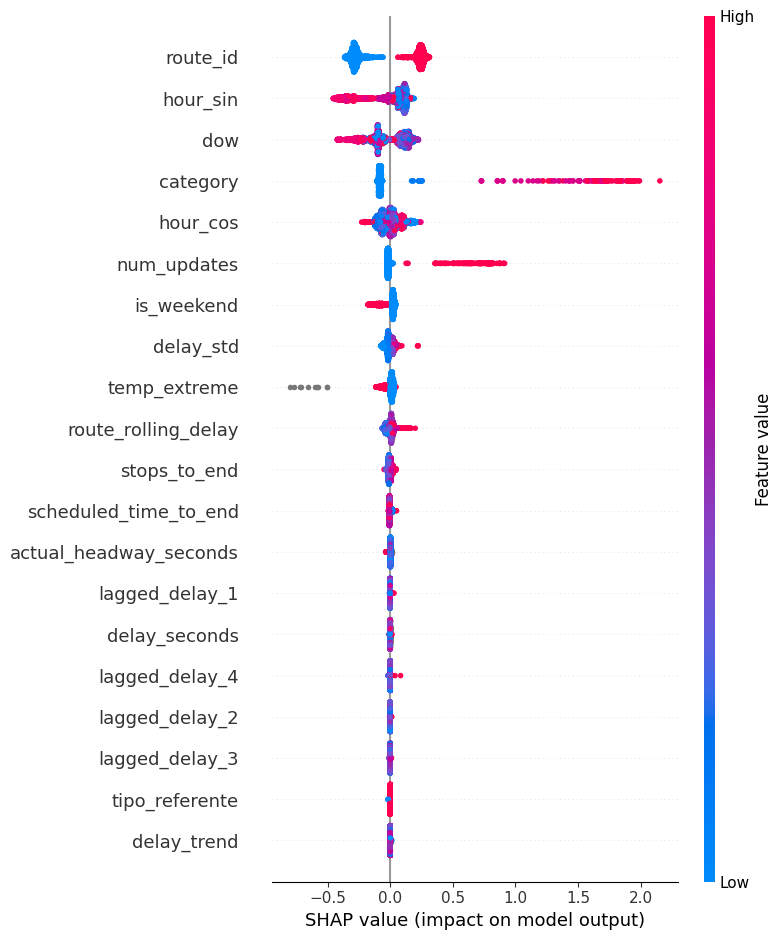

In [23]:
import shap

# Muestra aleatoria para SHAP (costoso con 1.8M filas)
sample = X_test.sample(5000, random_state=42)
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar')  
shap.summary_plot(shap_values, sample)                   

**Matriz de confusión con costes**

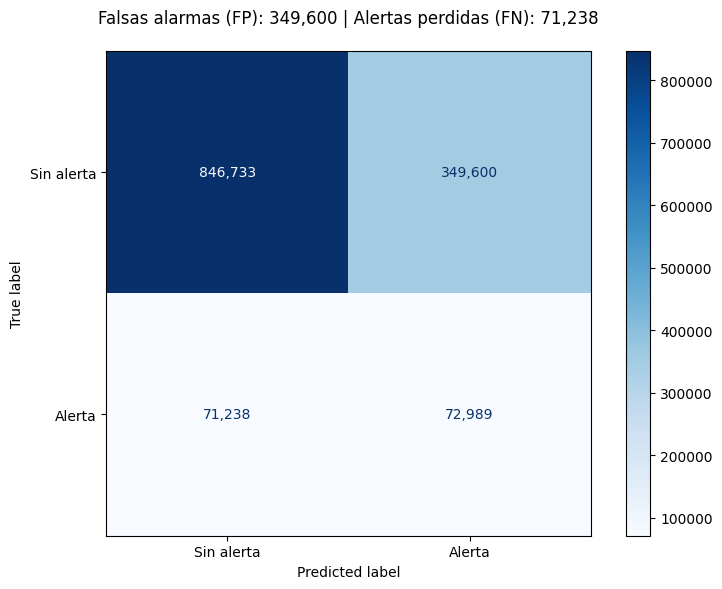

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=['Sin alerta', 'Alerta'],
    cmap='Blues',
    ax=ax,
    values_format=',d'
)

fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

ax.set_title(f'Falsas alarmas (FP): {fp:,} | Alertas perdidas (FN): {fn:,}', 
             pad=20,     
             fontsize=12)

plt.tight_layout() 
plt.show()

### Agragados cada 30 min

**Carga de datos desde MinIO**

In [25]:
import os
import sys
import pandas as pd
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

ruta_raiz = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ruta_raiz not in sys.path:
    sys.path.insert(0, ruta_raiz)


access_key = os.getenv("MINIO_ACCESS_KEY")
if access_key is None:
    raise AssertionError("MINIO_ACCESS_KEY no definida.")

secret_key = os.getenv("MINIO_SECRET_KEY")
if secret_key is None:
    raise AssertionError("MINIO_SECRET_KEY no definida.")


try:
    df = download_df_parquet(
        access_key=access_key,
        secret_key=secret_key,
        object_name=f"grupo5/aggregations/DataFrameGroupedByMin=30.parquet",
    )
except Exception as e:
        print(f"  Sin datos: {e}")


print(f"  df: {len(df):,} filas")


  df: 18,494,599 filas


In [26]:
df

,stop_id,route_id,direction,merge_time,is_unscheduled_max,is_weekend_max,temp_extreme_max,afecta_previo_max,afecta_durante_max,afecta_despues_max,...,tipo_referente_Parade_sum,tipo_referente_Street Event_sum,tipo_referente_nba_sum,tipo_referente_nhl_sum,tipo_referente_Concierto_sum,tipo_referente_Athletic Race / Tour_sum,tipo_referente_mlb_sum,tipo_referente_baseball/mlb_sum,tipo_referente_basketball/nba_sum,tipo_referente_hockey/nhl_sum
0,101N,1,N,2025-01-01 01:00:00,False,0,1.0,0,0,0,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
1,101N,1,N,2025-01-01 02:00:00,False,0,1.0,0,0,0,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2,101N,1,N,2025-01-01 02:30:00,False,0,1.0,0,0,0,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3,101N,1,N,2025-01-01 03:00:00,False,0,0.0,0,0,0,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
4,101N,1,N,2025-01-01 03:30:00,False,0,0.0,0,0,0,...,0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18494594,S31S,SI,S,2025-12-31 09:30:00,False,0,1.0,0,0,0,...,0,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0
18494595,S31S,SI,S,2025-12-31 10:00:00,False,0,1.0,0,0,0,...,0,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0
18494596,S31S,SI,S,2025-12-31 10:30:00,False,0,1.0,0,0,0,...,0,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0
18494597,S31S,SI,S,2025-12-31 11:00:00,False,0,0.0,0,0,0,...,0,0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0


**Selección de features y target**

In [27]:
#Seleccion de variables
features = [
    "delay_seconds_mean",
    "lagged_delay_1_mean",
    "lagged_delay_2_mean",
    "route_rolling_delay_mean",
    "actual_headway_seconds_mean",
    "seconds_since_last_alert_mean",
    "afecta_previo_max",
    "hour_sin_first",
    "hour_cos_first",
    "dow_first",
    "is_weekend_max",
    "is_unscheduled_max",
    "temp_extreme_max",
    "stops_to_end_mean",
    "scheduled_time_to_end_mean",
    "num_updates_sum",
    "match_key_nunique",
    "direction",
    "route_id",
]
target = 'alert_in_next_15m_max'


# Eliminar filas sin target
df = df.dropna(subset=[target]).copy()
df[target] = df[target].astype(int)

**Filtro que elimina paradas que no tienen alerta en 15m pero su comportamiento puede estar alterado por alerta en 30m**

In [28]:
mask_positivos = df[target] == 1
mask_negativos_limpios = (
    df['alert_in_next_30m_max'] == 0            
)

df = df[mask_positivos | mask_negativos_limpios].copy()
df = df.reset_index(drop=True)

print(f"Dataset tras filtrar negativos ambiguos: {len(df):,} filas")
print(f"  Positivos: {df[target].sum():,} ({df[target].mean()*100:.1f}%)")
print(f"  Negativos: {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%)")

Dataset tras filtrar negativos ambiguos: 17,605,375 filas
  Positivos: 2,591,389 (14.7%)
  Negativos: 15,013,986 (85.3%)


**División de datos en Train-Val-Test**

In [29]:
df_sorted = df.sort_values('merge_time')

#Division X e y
X = df_sorted[features]
y = df_sorted[target]

print(f"Features: {len(features)}")
print(f"Filas:    {len(X):,}")
print(f"\nDistribución del target:")
print(y.value_counts(normalize=True).round(3))


#División de los datos en Entrenamiento-Validación-Test

dias = df_sorted['merge_time'].dt.date.unique()
dias_ordenados = sorted(dias)

total_dias = len(dias_ordenados)
corte_70   = dias_ordenados[int(total_dias * 0.70)]
corte_85   = dias_ordenados[int(total_dias * 0.85)]

print(f"Total días: {total_dias}")
print(f"Primer día: {dias_ordenados[0]}")
print(f"Último día: {dias_ordenados[-1]}")
print(f"\nCorte train (70%): {corte_70}")
print(f"Corte val   (85%): {corte_85}")


train = df_sorted[df_sorted['merge_time'].dt.date <  corte_70]
val   = df_sorted[(df_sorted['merge_time'].dt.date >= corte_70) &
           (df_sorted['merge_time'].dt.date <  corte_85)]
test  = df_sorted[df_sorted['merge_time'].dt.date >= corte_85]

X_train, y_train = train[features], train[target]
X_val,   y_val   = val[features],   val[target]
X_test,  y_test  = test[features],  test[target]

n = len(df)
print(f"Train: {len(train):,} ({len(train)/n*100:.0f}%)  "
      f"{train['merge_time'].min().date()} → {train['merge_time'].max().date()}")
print(f"Val:   {len(val):,} ({len(val)/n*100:.0f}%)  "
      f"{val['merge_time'].min().date()} → {val['merge_time'].max().date()}")
print(f"Test:  {len(test):,} ({len(test)/n*100:.0f}%)  "
      f"{test['merge_time'].min().date()} → {test['merge_time'].max().date()}")

Features: 19
Filas:    17,605,375

Distribución del target:
alert_in_next_15m_max
0    0.853
1    0.147
Name: proportion, dtype: float64
Total días: 365
Primer día: 2025-01-01
Último día: 2025-12-31

Corte train (70%): 2025-09-13
Corte val   (85%): 2025-11-07
Train: 12,100,046 (69%)  2025-01-01 → 2025-09-12
Val:   2,741,803 (16%)  2025-09-13 → 2025-11-06
Test:  2,763,526 (16%)  2025-11-07 → 2025-12-31


**Encoding de categorías**

In [30]:
#Encodear categorías

from sklearn.preprocessing import OrdinalEncoder

cols_ordinal_enc = ['route_id', 'direction']   

#Ordinal Encoding
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train[cols_ordinal_enc] = enc.fit_transform(X_train[cols_ordinal_enc])
X_val[cols_ordinal_enc]   = enc.transform(X_val[cols_ordinal_enc])
X_test[cols_ordinal_enc]  = enc.transform(X_test[cols_ordinal_enc])

print("✓ Encoding completado")

✓ Encoding completado


**Búsqueda de los mejores hiperparámetros empleando optuna**

In [31]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import (average_precision_score, classification_report, roc_auc_score,
                              average_precision_score, f1_score,
                              recall_score, precision_score)

# Ratio de desbalance para scale_pos_weight
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Ratio desbalance: {ratio:.1f}:1")

def objective(trial):
    params = {
        'max_depth':          trial.suggest_int('max_depth', 3, 10),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 100),
        'gamma':              trial.suggest_float('gamma', 0, 10),
        'learning_rate':      trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators':       trial.suggest_int('n_estimators', 200, 800),
        'subsample':          trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.4, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-6, 100, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-6, 100, log=True),
        'max_delta_step':     trial.suggest_float('max_delta_step', 0, 10),
        'scale_pos_weight':   ratio,
        'tree_method':        'hist',
        'eval_metric':        'aucpr',
        'early_stopping_rounds': 30,
    }
    modelo = XGBClassifier(**params, random_state=42)
    modelo.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = modelo.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)
print(study.best_params)

[I 2026-03-23 22:36:36,126] A new study created in memory with name: no-name-8a5336c0-32a9-4568-bdaf-94a8888b688f


Ratio desbalance: 5.8:1


[I 2026-03-23 22:46:29,490] Trial 0 finished with value: 0.5555248951035117 and parameters: {'max_depth': 8, 'min_child_weight': 88, 'gamma': 6.27593429587292, 'learning_rate': 0.0114018263639788, 'n_estimators': 503, 'subsample': 0.4543901264979957, 'colsample_bytree': 0.6546680279467009, 'colsample_bylevel': 0.41851684807818484, 'reg_alpha': 0.4470930136879378, 'reg_lambda': 5.5212136451329056e-05, 'max_delta_step': 4.69882567748378}. Best is trial 0 with value: 0.5555248951035117.
[I 2026-03-23 22:52:52,488] Trial 1 finished with value: 0.5572735618049574 and parameters: {'max_depth': 4, 'min_child_weight': 42, 'gamma': 5.001342668287684, 'learning_rate': 0.1055337313197306, 'n_estimators': 541, 'subsample': 0.4949646081264256, 'colsample_bytree': 0.8415575898900001, 'colsample_bylevel': 0.5279915059642027, 'reg_alpha': 0.0005090284104819049, 'reg_lambda': 8.803032214574358e-05, 'max_delta_step': 2.422216878987075}. Best is trial 1 with value: 0.5572735618049574.
[I 2026-03-23 23:04

{'max_depth': 7, 'min_child_weight': 54, 'gamma': 2.8069092517345418, 'learning_rate': 0.07612070190188074, 'n_estimators': 586, 'subsample': 0.6827272796265806, 'colsample_bytree': 0.9532296764845091, 'colsample_bylevel': 0.9934894024143218, 'reg_alpha': 0.007756850219225101, 'reg_lambda': 4.575555366136456, 'max_delta_step': 3.8068237192301666}


**Entrenamiento del modelo empleando los mejores parámetros**

In [32]:
best_params = study.best_params

params_fijos = {
    'n_estimators': 500,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'eval_metric': 'aucpr',
    'random_state': 42
}

parametros = {**params_fijos, **best_params}

modelo_final = XGBClassifier(**parametros)
modelo_final.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.9934894024143218
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9532296764845091
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.da

**Evaluacion del modelo**

In [33]:
import numpy as np

#Evaluación del modelo

y_prob = modelo_final.predict_proba(X_test)[:, 1]

# Threshold óptimo por F1
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_test, (y_prob >= t).astype(int),
                        zero_division=0) for t in thresholds]
threshold_opt = thresholds[np.argmax(f1_scores)]
y_pred = (y_prob >= threshold_opt).astype(int)


print(f"Threshold óptimo: {threshold_opt:.2f}")
print(f"\nAUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_prob):.4f}")
print(f"F1      : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall  : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"\n{classification_report(y_test, y_pred)}")

Threshold óptimo: 0.65

AUC-ROC : 0.8105
PR-AUC  : 0.5477
F1      : 0.4917
Recall  : 0.4989
Precision: 0.4848

              precision    recall  f1-score   support

           0       0.91      0.91      0.91   2357279
           1       0.48      0.50      0.49    406247

    accuracy                           0.85   2763526
   macro avg       0.70      0.70      0.70   2763526
weighted avg       0.85      0.85      0.85   2763526



**Curva Precision-Recall con area sombreada**

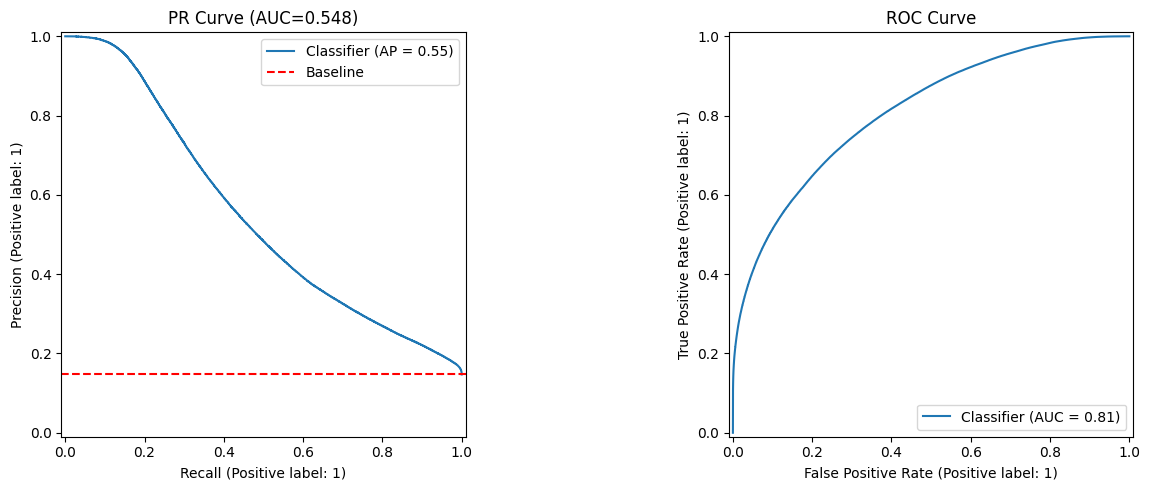

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva PR
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[0])
axes[0].set_title(f'PR Curve (AUC={average_precision_score(y_test, y_prob):.3f})')
axes[0].axhline(y=y_test.mean(), color='r', linestyle='--', label='Baseline')
axes[0].legend()

# Curva ROC
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].set_title('ROC Curve')
plt.tight_layout()

**Importancia de features con SHAP**

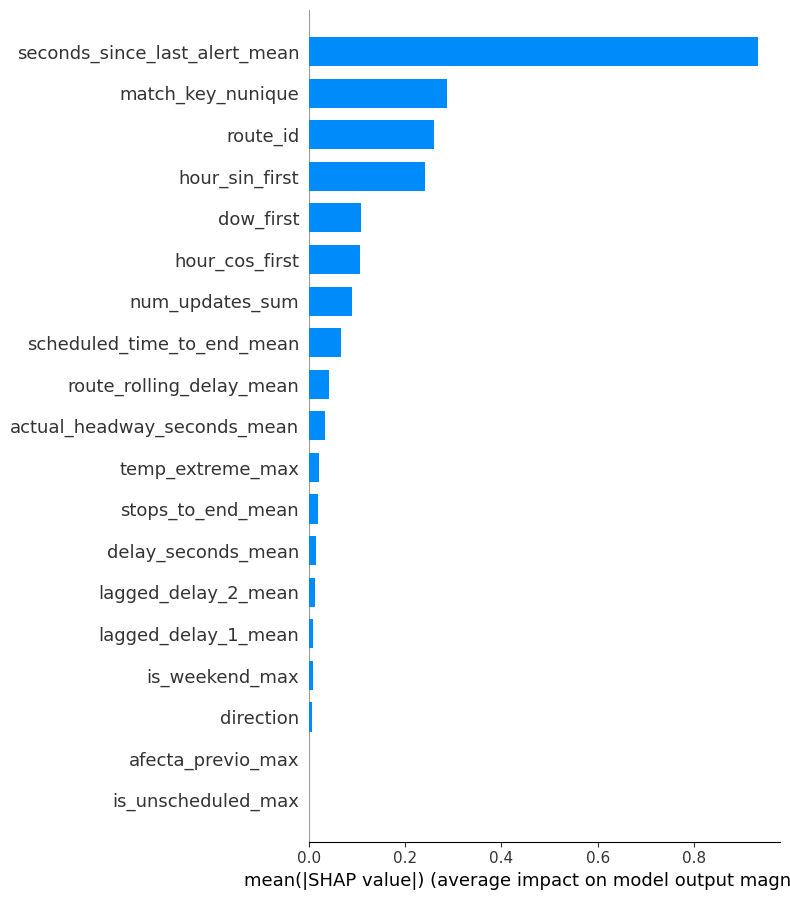

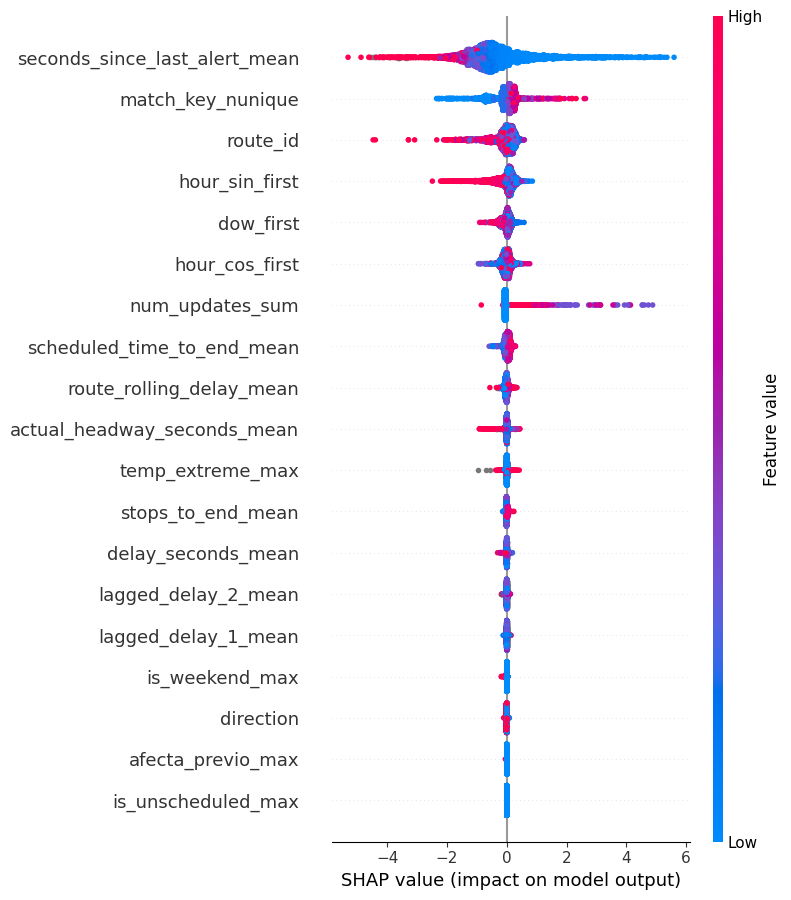

In [35]:
import shap

# Muestra aleatoria para SHAP (costoso con 1.8M filas)
sample = X_test.sample(5000, random_state=42)
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(sample)

shap.summary_plot(shap_values, sample, plot_type='bar')   # importancia global
shap.summary_plot(shap_values, sample)                     # dirección del efecto

**Matriz de confusión con costes**

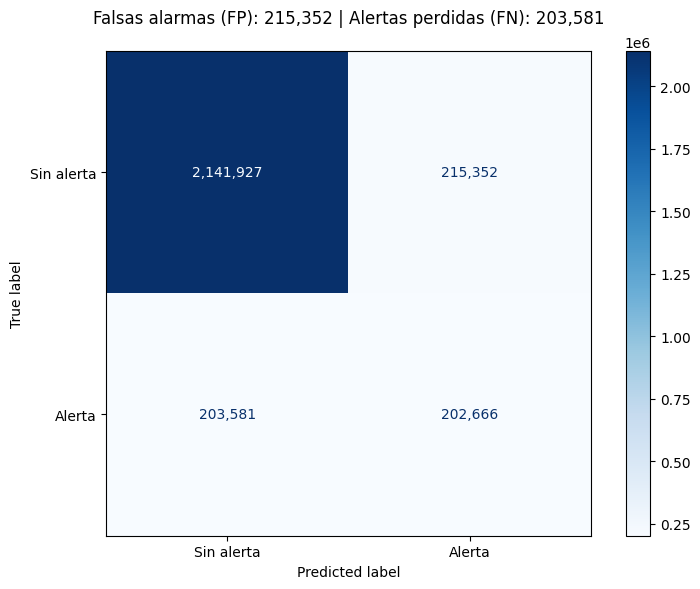

In [36]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred,
    display_labels=['Sin alerta', 'Alerta'],
    cmap='Blues',
    ax=ax,
    values_format=',d'
)

fp = ((y_pred == 1) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

ax.set_title(f'Falsas alarmas (FP): {fp:,} | Alertas perdidas (FN): {fn:,}', 
             pad=20,     
             fontsize=12)

plt.tight_layout() 
plt.show()